# Introduction to Python in Chemistry Lesson 4

Please first run the import cells below, this gives us the useful software packages we need. 

In [83]:
# 1
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem.rdMolDescriptors import CalcExactMolWt, CalcMolFormula

We are going to learn to read in some data from a separate file. this file is called `chem_mp_bp_dataset.csv`.

The file ending `.csv` stands for comma separated values. Unfortunately, not all `.csv` files actually have comma separated values, but this file should.

You can check how it is saved by opeining it in a text editor, such as notepad. Be careful not to edit it accidentally!

Note in the functon call below, we are using the pandas library as `pd`, which we `import` it as above. The file name is entered as a string giving the path to the file. This will save all the data in a `DataFrame`, which will make manipulating the data more easy. 

*Unless you are using VSCode, whereas this will be more complex

You can change where the computer looks for the file, by putting in the whole path. 

In [112]:
# 2
df = pd.read_csv('./data/bp-mp-data/chem_mp_bp_dataset.csv')
df.info() # shows us some information about the data frame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1629 entries, 0 to 1628
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1629 non-null   int64  
 1   compLabel         1629 non-null   object 
 2   formula           1629 non-null   object 
 3   bp                1629 non-null   float64
 4   bpUnitLabel       1629 non-null   object 
 5   mp                1629 non-null   float64
 6   mpUnitLabel       1629 non-null   object 
 7   canonical_smiles  1629 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 101.9+ KB


You will see there is a column called `Unnamed: 0`, this is the index, we can delete it. 

In [113]:
# 3
df = df.drop('Unnamed: 0', axis=1) 
# this will throw an error if you try to run it more than once. rerun block 2 first
df.head() # shows us the top 5 rows of the dataframe.

,compLabel,formula,bp,bpUnitLabel,mp,mpUnitLabel,canonical_smiles
0,helium,He,-268.9,degree Celcius,-272.2,degree Celcius,[He]
1,carbon monoxide,CO,-191.7,degree Celcius,-205.0,degree Celsius,[C-]#[O+]
2,fluorine,F,-188.3,degree Celcius,-219.4,degree Celcius,FF
3,nitric oxide,NO,-151.7,degree Celcius,-163.9,degree Celcius,[N]=O
4,oxygen difluoride,F₂O,-145.6,degree Celcius,-223.9,degree Celcius,O(F)F


In [130]:
# 4
df.head()

,compLabel,formula,bp,bpUnitLabel,mp,mpUnitLabel,canonical_smiles
0,helium,He,-268.9,degree Celcius,-272.2,degree Celcius,[He]
1,carbon monoxide,CO,-191.7,degree Celcius,-205.0,degree Celsius,[C-]#[O+]
2,fluorine,F,-188.3,degree Celcius,-219.4,degree Celcius,FF
3,nitric oxide,NO,-151.7,degree Celcius,-163.9,degree Celcius,[N]=O
4,oxygen difluoride,F₂O,-145.6,degree Celcius,-223.9,degree Celcius,O(F)F


In [131]:
# 5
grp4 = ['C', '[SiH4]','[GeH4]', '[SnH4]']
# these are the smiles strings for the group 4 hydrides
for ind, row in df.iterrows():
    if row['canonical_smiles'] in grp4:
        print(row.name, row.compLabel, row.formula, row.bp)
        

7 silane H₄Si -111.7
11 germane GeH₄ -88.3
431 methane CH₄ -161.48
432 stannane  SnH₄ -52.0


So now we need to make an array, with the boiling points in the right order. Lets sort by molar mass. Use RDKit to calculate it.

[SiH4] -111.7 32.008226658
[GeH4] -88.3 77.952477928
C -161.48 16.031300127999998
[SnH4] -52.0 123.933494828


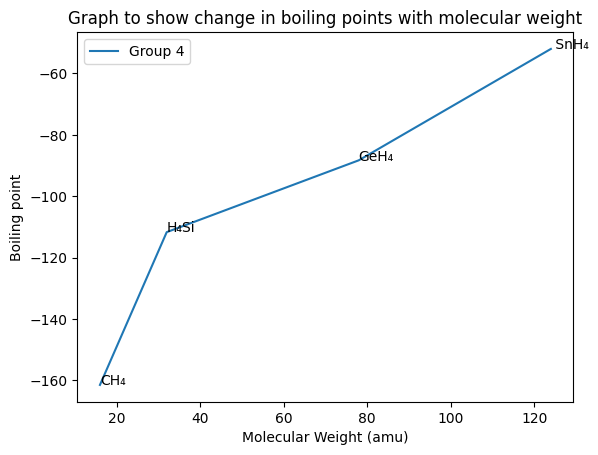

In [132]:
# 6
# initialises a list to save the ddata we find
mwbp4 = []

#iterates through the dataset checking to see if the smiles string matches
for ind, row in df.iterrows():
    if row['canonical_smiles'] in grp4:
        #make mol object using the smiles string. 
        mol = Chem.MolFromSmiles(row.canonical_smiles)
        # RDKit can calculate molar mass using this object
        mw = CalcExactMolWt(mol)
        # Print to check what you are getting
        print(row.canonical_smiles, row.bp, mw)
        # put the data in to a list in the form of a tuple
        mwbp4.append((mw, row.bp, row.formula))

#this code sorts the list in to molar mass order
mwbp.sort(key=lambda tup: tup[0])

#this makes it in to two separate lists
mws, bps, forms = zip(*mwbp)

# this plots the points, and makes the labels for the line
plt.plot(mws, bps, label='Group 4')
plt.legend()

#This labels the points with the formulae
for i, form in enumerate(forms):
    plt.annotate(form, (mws[i], bps[i]));

#label axes and make a title
plt.title('Graph to show change in boiling points with molecular weight')
plt.xlabel('Molecular Weight (amu)')
plt.ylabel('Boiling point');

In [133]:
#7
# these are the smiles strings for the group 5 and 6 hydrides
grp5 = ['N', 'P','[AsH3]', '[SbH3]']
grp6 = ['O', 'S','[TeH2]', '[SeH2]']


TODO: 
- plot a graph with the boiling points for hydrides in group 4, 5 and 6
- the smiles strings are above
- make sure you have fully labelled your graph
- What do you learn from this graph. 
- If you finish.. how efficient is your code?

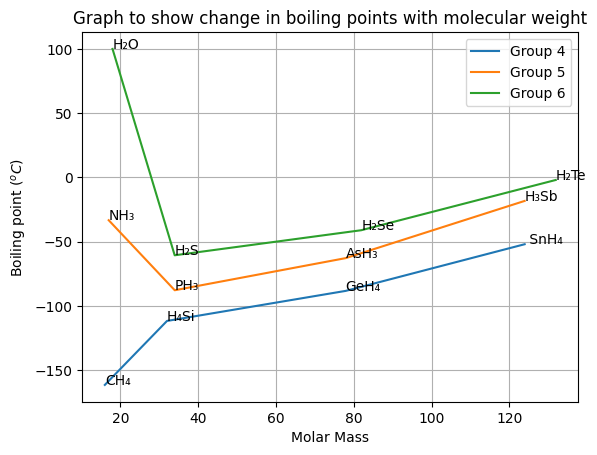

In [134]:
# 8
# initialises lists to save the data we find
mwbp4 = []
mwbp5 = []
mwbp6 = []

grp456 = grp4+grp5+grp6 # makes list of all the smiles strings we are looking for

#itertes through the dataset checking to see if the smiles string matches
for ind, row in df.iterrows():
    if row['canonical_smiles'] in grp456:
        #make mol object using the smiles string. 
        mol = Chem.MolFromSmiles(row.canonical_smiles)
        # RDKit can calculate molar mass using this object
        mw = CalcExactMolWt(mol)
        # put the data in to a list in the form of a tuple
        if row['canonical_smiles'] in grp4:
            mwbp4.append((mw, row.bp, row.formula))
        if row['canonical_smiles'] in grp5:
            mwbp5.append((mw, row.bp, row.formula))
        if row['canonical_smiles'] in grp6:
            mwbp6.append((mw, row.bp, row.formula))

lsts = [mwbp4, mwbp5, mwbp6]

for i, lst in enumerate(lsts):
    #this code sorts the lists into molar mass order
    lst.sort(key=lambda tup: tup[0])
    #this makes it in to two separate lists
    mws, bps, forms = zip(*lst)
    # this plots the points, and makes the labels for the line
    plt.plot(mws, bps, label=f'Group {i+4}')
    for i, form in enumerate(forms):
        plt.annotate(form, (mws[i], bps[i]));

#label axes and make a title
plt.legend()
plt.title('Graph to show change in boiling points with molecular weight')
plt.xlabel('Molar Mass')
plt.ylabel('Boiling point ($^oC$)')
plt.grid();

My code is moderately efficient because i don't iterate though the dataframe more than once

I put the plotting code in the for loop to avoid writing it all out four times

having four if statements isn't efficient, i could improve this by having more code written out. 

# Hydrogen Bonds


In [5]:
# 9
